# **Tarea 1. Networkx**
Elaborar en Python un código para resolver los problemas de:

- Árbol de Expansión Mínima
- Ruta más corta
- Flujo Máximo

Elaborado por: Jorge Luis Magaña Pichardo

# **1.** **ÁRBOL DE EXPANSIÓN MÍNIMA** 

El siguiente código contiene la forma de resolver ejercicios de **ÁRBOL DE EXPANSIÓN MÍNIMA**, con las lbrerías **NETWORKX** y **MATPLOTLIB.PYPLOT**

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

Inicialmente tenemos que agregar en una lista los nodos con el peso de los arcos (Distancia de los arcos) en forma de triadas, la notación que se usara para cada triada será:
$$
Nodo = (Nombre \ de \ Nodo \  Inicial, \  Nombre \  de \ Nodo \  Conectado,\  Distancia \ de \ arco)
$$
Como lo muestro en la siguiente lista de nodos, en donde el primer nodo que tomo es el: 
$$
N1 = (1, 2, 5)
$$
Quiere decir que del nodo 1 hay un arco al nodo 2 con distancia de 1.

In [4]:
#Agregaré  los nodos con el peso de los arcos (DISTANCIA)
Nodos = [
    ( 1, 2, 5),
    ( 1, 3, 1),
    ( 3, 2, 2),
    ( 2, 6, 6),
    ( 2, 4, 7),
    ( 4, 5, 3),
    ( 3, 4, 6),
    ( 4, 6, 4),
    ( 6, 7, 2),
    ( 5, 7, 9),
    ( 6, 5, 5),
    ( 4, 7, 6),
    ( 2, 5, 1)

]

A partir de crear una lista con los nodos se generá un grafo con la librería **networkx**, usando el comando "nx.Graph()", para agregar al grafo todos nuestros nodos, es necesario hacer un ciclo for señalando las variables:
$$
u = Nodo \ inicial \quad v = Nodo \ conectado \ al \ nodo \ inicial \quad w = Distancia
$$
en donde agregaremos como nodos con arcos al grafo usando el comando "F.add_edge(u,v,w)" (F es el nombre del GRAFO)

In [5]:
#Grafo
F = nx.Graph()
for u, v, w in Nodos:
    F.add_edge(u, v, weight=w)

El comando "nx.spring_layout()" es para que las posiciones entre las distancias tengan sentido y no se encimen al momento de graficarlos, para tener un modelo adecuado, se usan los argumentos (Grafo, Semlla). en donde la semilla es una forma predeterminada de hacer el grafo.


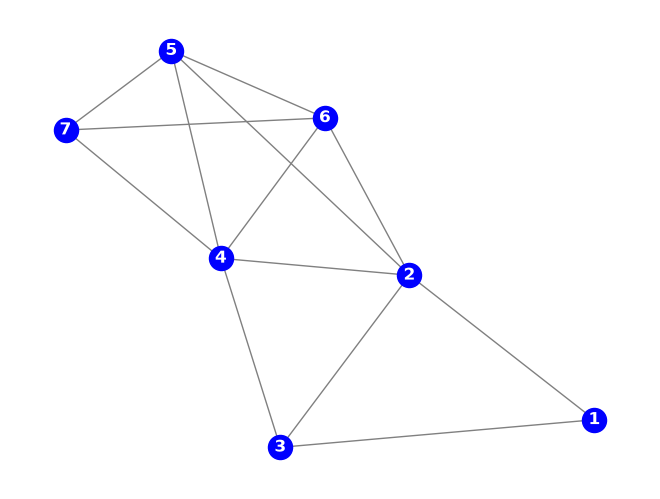

In [6]:
# Dibujar el grafo con distancia (pesos) entre nodos
pos = nx.spring_layout(F, seed=10)  # Posiciones de los nodos
nx.draw(F,pos, with_labels=True, node_color='blue', edge_color='gray', font_color='white', font_weight='bold')

Usando el comando de "nx.minimum_spanning_tree()" encontramos la solución mínima para el árbol de expansión, se imprime la solución y nos devuelve una lista con los nodos conectados que contienen la expansión mínima en el orden siguiente:
$$
Nodo \ de \ expansión \ mínima = (Nodo \ inicial,\ Nodo \ conectado, \ Distancia \ mínima \ entre \ nodos)
$$

In [7]:
#Árbol de expansión mínima
aem = nx.minimum_spanning_tree(F)
print("Árbol de expansión mínima:")
print(aem.edges(data=True))


Árbol de expansión mínima:
[(1, 3, {'weight': 1}), (2, 5, {'weight': 1}), (2, 3, {'weight': 2}), (6, 7, {'weight': 2}), (6, 4, {'weight': 4}), (4, 5, {'weight': 3})]


Se puede saber la distancia total del arco con el comando **"Grafo.size(weight='weight')"**, y se grafica el grafo con "nx.draw(Expansión minima, Posiciones, funciones...)"

Distancia total del árbol de expansión mínima: 13.0


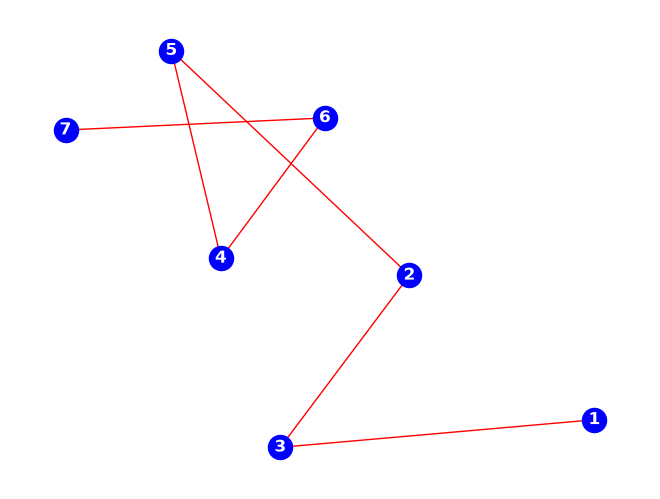

In [8]:

print("Distancia total del árbol de expansión mínima:", aem.size(weight='weight'))
nx.draw(aem,pos, with_labels=True, node_color='blue', edge_color='red', font_color='white', font_weight='bold')


# **2.** **RUTA MÁS CORTA**

El siguiente código contiene la forma de resolver ejercicios de **RUTA MÁS CORTA**, con las lbrerías **NETWORKX** y **MATPLOTLIB.PYPLOT**

In [1]:
import networkx as nx
import matplotlib.pyplot as plt


Se hizo una función de la ruta más corta,con parametros 
$$
ND = \ Nodos \  y \  Distancia, \ O = Origen, \ D = Destino, \ Dir = Dirigido
$$

Donde ND tiene la entrada del grafo, O es el punto de origen de la red, D al destino de la red, Dirigido revisa su es una red dirigida o no

In [37]:
def rmc(ND, O, D, Dir=False):
    # 1. Crear el grafo (Dirigido o No Dirigido)
    G = nx.DiGraph() if Dir else nx.Graph()
    
    # 2. Agregar las aristas con su peso (distancia, costo, tiempo, etc.)
    G.add_weighted_edges_from(ND)
    
    # Validar que los nodos existan en el grafo
    if O not in G or D not in G:
        raise ValueError("El nodo de origen o destino no existe en el grafo.")

    # 3. Calcular la Ruta Más Corta y su Distancia Total
    ruta_mas_corta = nx.shortest_path(G, source=O, target=D, weight='weight')
    distancia_total = nx.shortest_path_length(G, source=O, target=D, weight='weight')
    
  

    
    return ruta_mas_corta, distancia_total, G




Hacemos un ejemplo con el grafo anterior, pero ahora con la ruta dirigida, ya que el grafo de ejemplo que estamos usando es el siguiente:
 
![Grafo de ejemplo](Grafo_1.png)

Notemos que el Origen es 1 y el Destino es 7, es una ruta dirigida, quiere decir que el vector indica que (1,2,3) el nodo 1 va dirgido al 3 con distancia o peso 3

In [38]:
Grafo_dirigido = [
    ( 1, 2, 5),
    ( 1, 3, 1),
    ( 3, 2, 2),
    ( 2, 6, 6),
    ( 4, 3, 7),
    ( 2, 4, 7),
    ( 4, 5, 3),
    ( 3, 4, 6),
    ( 4, 6, 4),
    ( 6, 7, 2),
    ( 5, 7, 9),
    ( 5, 6, 5),
    ( 4, 7, 6),
    ( 2, 5, 1),
    ( 6, 2, 7),
    ( 5, 4, 3)

]
Dirigido = True
Origen = 1
Destino = 7

De la función obtenemos "RUTA" la cual es la ruta mas corta, "Distancia" que es la distancia total de la ruta mas corta y "Grafo" que es el grafo creado a partir de los nodos y aristas proporcionados.


In [39]:
Ruta, Distancia, Grafo = rmc(Grafo_dirigido, Origen, Destino, Dirigido)
print(f"RESULTADO DE LA RUTA MÁS CORTA ({Origen} -> {Destino})")
print(f"Ruta: {' a '.join(map(str, Ruta))}")
print(f"Distancia Total: {Distancia}")



RESULTADO DE LA RUTA MÁS CORTA (1 -> 7)
Ruta: 1 a 3 a 2 a 6 a 7
Distancia Total: 11


Aristas_ruta hace referencia a las aristas que forman parte de la ruta más corta entre el nodo de origen y el nodo de destino. Se construye como una lista de tuplas, donde cada tupla representa una arista conectando dos nodos consecutivos en la ruta.


In [40]:
pos = nx.spring_layout(Grafo, seed=20)  # Disposición visual de los nodos

 # Identificar aristas que pertenecen a la ruta más corta
aristas_ruta = [(Ruta[i], Ruta[i+1]) for i in range(len(Ruta)-1)]


Aquí en colores_nodos se asigna un color rojo a los nodos que están en la ruta más corta y azul a los demás, en colores_aristas se asigna un color rojo a las aristas que están en la ruta más corta y gris a las demás, en anchos_aristas se asigna un grosor mayor a las aristas que están en la ruta más corta y un grosor menor a las demás.

In [41]:
# Colores para nodos y aristas
colores_nodos = ["red" if n in Ruta else 'blue' for n in Grafo.nodes()]
colores_aristas = ["red" if (u, v) in aristas_ruta else 'gray' for u, v in Grafo.edges()]
anchos_aristas = [3 if (u, v) in aristas_ruta else 1.5 for u, v in Grafo.edges()]



Con la función nx.draw_networkx_edges podemos dibujar las aristas del grafo, y con la opción edgelist podemos especificar qué aristas queremos dibujar. En este caso, dibujaremos todas las aristas del grafo, pero resaltaremos las que pertenecen a la ruta más corta.

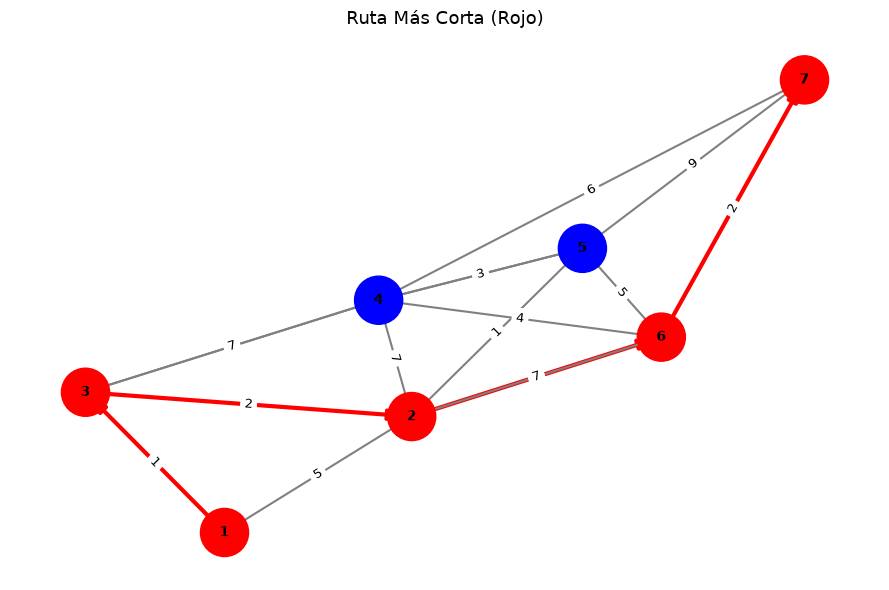

In [42]:
plt.figure(figsize=(9, 6))

# Dibujar nodos y aristas
nx.draw_networkx_nodes(Grafo, pos, node_color=colores_nodos, node_size=1200)
nx.draw_networkx_edges(Grafo, pos, edge_color=colores_aristas, width=anchos_aristas, arrowsize=15)
nx.draw_networkx_labels(Grafo, pos, font_weight="bold", font_size=10)

# Dibujar las etiquetas con los pesos en las aristas
pesos_aristas = nx.get_edge_attributes(Grafo, 'weight')
nx.draw_networkx_edge_labels(Grafo, pos, edge_labels=pesos_aristas, font_size=9)


plt.title("Ruta Más Corta (Rojo)", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()

# **3. Flujo Máximo**

Para calcular el flujo máximo en un grafo dirigido, A continuación, se muestra un ejemplo de cómo hacerlo utilizando la biblioteca NetworkX en Python.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt



Se hace una función para el flujo máximo, en donde se le ingresan terminos como apacidades es una lista de tuplas (origen, destino, capacidad), origen es el nodo de origen y destino es el nodo de destino

In [48]:

def flujo_maximo(capacidades, origen, destino):

    # 1. Crear Grafo Dirigido
    G = nx.DiGraph()
    
    # 2. Agregar aristas con el atributo 'capacity'
    for u, v, cap in capacidades:
        G.add_edge(u, v, capacity=cap)

    # 3. Calcular el Flujo Máximo
    # Retorna: (valor_flujo_maximo, diccionario_con_el_flujo_por_arista)
    flujo_valor, flujo_dict = nx.maximum_flow(G, origen, destino)

    return flujo_valor, flujo_dict, G




Usaremos el grafo dado en el ejemplo de Classroom:

![Ejemplo](grafo.png)

In [ ]:
capacidades = [
    (1, 3, 14),
    (3, 1, 0),
    (1, 5, 4),
    (5, 1, 0),
    (1, 2, 8),
    (2, 1, 0),
    (2, 3, 5),
    (3, 2, 10),
    (2, 5, 6),
    (5, 2, 0),
    (2, 4, 7),
    (4, 2, 6),
    (3, 5, 10),
    (5, 3, 0),
    (3, 4, 9),
    (4, 3, 7),
    (4, 5, 5),
    (5, 4, 0)
]
Origen = 1
Destino = 4
flujo, flujo_dict,G = flujo_maximo(capacidades, Origen, Destino)

In [51]:
print(f"RESULTADO DEL FLUJO MÁXIMO ({Origen} -> {Destino})")
print(f"Flujo Máximo Total: {flujo} unidades")



RESULTADO DEL FLUJO MÁXIMO (1 -> 4)
Flujo Máximo Total: 16 unidades


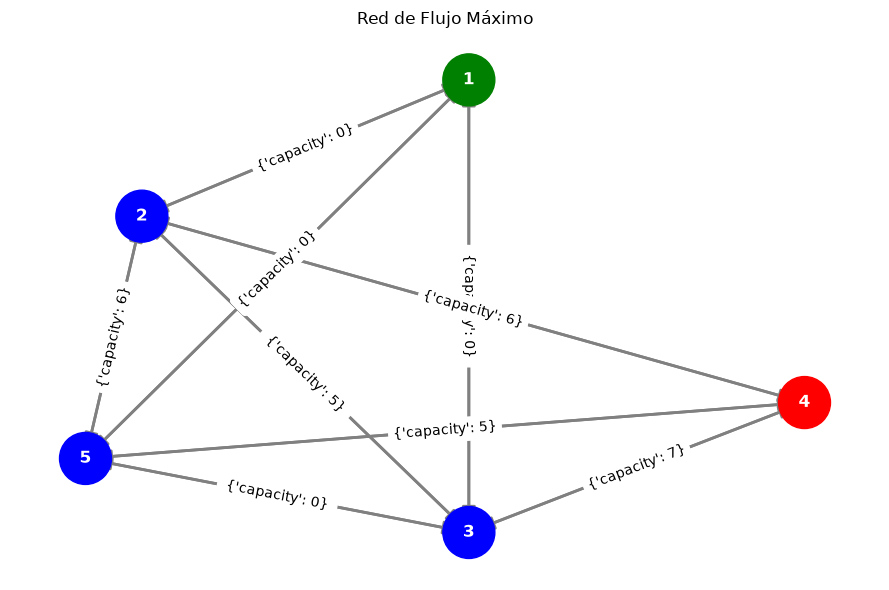

In [56]:

pos = nx.spring_layout(G, seed=42)

# Colores para nodos
node_colors = []
for node in G.nodes():
    if node == Origen:
        node_colors.append('green')  # Verde para la fuente
    elif node == Destino:
        node_colors.append('red')  # Rojo para el sumidero
    else:
        node_colors.append('blue')  # Azul para nodos intermedios

plt.figure(figsize=(9, 6))

# Dibujar nodos y aristas
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1400)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=2, arrowsize=20)
nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold')


nx.draw_networkx_edge_labels(G, pos, font_size=10)

plt.title("Red de Flujo Máximo", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()